# ANALSIS EXPLORATORIO DE LOS DATOS

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('/content/train.csv')


In [5]:
print("No. of rows: ", df.shape[0])
print("No. of columns: ", df.shape[1])

No. of rows:  1458644
No. of columns:  11


In [6]:
print("No. de filas :", df.shape[0])
print("No. de columnas:", df.shape[1])

No. de filas : 1458644
No. de columnas: 11


In [7]:
df = df.reset_index(drop=True)
#Mantener secuencia en los indices

In [8]:
df.head()


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [9]:
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


Revisaremos las variables pickup_datetime y dropoff_datetime debido a que son de tipo object en lugar de datetime64.

In [10]:
# Missing values
print(df.isnull().sum())


id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64


In [11]:
df.dtypes

,0
id,object
vendor_id,int64
pickup_datetime,object
dropoff_datetime,object
passenger_count,int64
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
store_and_fwd_flag,object


En el paso anterior verificamos el clase de variables y podemos ver que tenemos de todo tipo, seguido de esto estaremos haciendo unas modificaciones en los tipos de variables para un mejor manejo de los datos.

In [12]:
# Transformando las columnas de fecha y hora (pickup y dropoff) en objetos de tipo datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], format='%Y-%m-%d %H:%M:%S')
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'], format='%Y-%m-%d %H:%M:%S')

In [13]:
# Transformando vendor_id y store_and_fwd_flag a tipo de dato categórico
df['vendor_id'] = df['vendor_id'].astype('category')
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype('category')

In [14]:
# Convirtiendo la variable de "Sí/No" a 1 y 0 y transformándola en tipo de dato categórico
df['store_and_fwd_flag'] = 1 * (df.store_and_fwd_flag.values == 'Y')
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype('category')

In [15]:
# Muestra las primeras 10 filas
print(df.tail())

                id vendor_id     pickup_datetime    dropoff_datetime  \
1458639  id2376096         2 2016-04-08 13:31:04 2016-04-08 13:44:02   
1458640  id1049543         1 2016-01-10 07:35:15 2016-01-10 07:46:10   
1458641  id2304944         2 2016-04-22 06:57:41 2016-04-22 07:10:25   
1458642  id2714485         1 2016-01-05 15:56:26 2016-01-05 16:02:39   
1458643  id1209952         1 2016-04-05 14:44:25 2016-04-05 14:47:43   

         passenger_count  pickup_longitude  pickup_latitude  \
1458639                4        -73.982201        40.745522   
1458640                1        -74.000946        40.747379   
1458641                1        -73.959129        40.768799   
1458642                1        -73.982079        40.749062   
1458643                1        -73.979538        40.781750   

         dropoff_longitude  dropoff_latitude store_and_fwd_flag  trip_duration  
1458639         -73.994911         40.740170                  0            778  
1458640         -73.970184

In [16]:
print("Startdate: ", df['pickup_datetime'].min())
print("Enddate: ", df['pickup_datetime'].max())


Startdate:  2016-01-01 00:00:17
Enddate:  2016-06-30 23:59:39


Tenemos datos en un rango de los primeros seis meses del año 2016.

In [17]:
# Creando nuevas características a partir de las columnas de fecha y hora

# Para la fecha y hora de recogida (pickup)
df['dia_recogida'] = df['pickup_datetime'].dt.day          # Día del mes
df['hora_recogida'] = df['pickup_datetime'].dt.hour        # Hora del día
df['dia_semana_recogida'] = df['pickup_datetime'].dt.weekday  # Día de la semana (0: Lunes, 6: Domingo)

# Para la fecha y hora de llegada (dropoff)
df['dia_llegada'] = df['dropoff_datetime'].dt.day          # Día del mes
df['hora_llegada'] = df['dropoff_datetime'].dt.hour        # Hora del día
df['dia_semana_llegada'] = df['dropoff_datetime'].dt.weekday  # Día de la semana (0: Lunes, 6: Domingo)


In [18]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,dia_recogida,hora_recogida,dia_semana_recogida,dia_llegada,hora_llegada,dia_semana_llegada
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,0,455,14,17,0,14,17,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,0,663,12,0,6,12,0,6
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,19,11,1,19,12,1
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,0,429,6,19,2,6,19,2
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,0,435,26,13,5,26,13,5


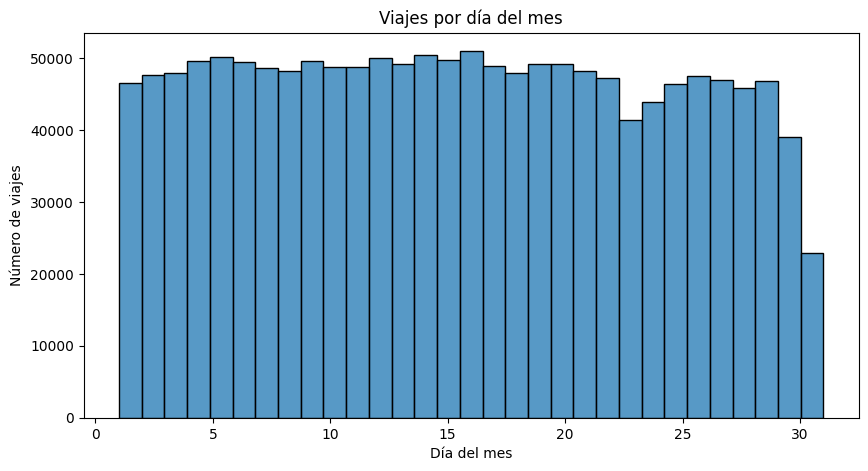

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns


#Grafico 1:Viajes por día del mes.
plt.figure(figsize=(10, 5))
sns.histplot(df['dia_recogida'], bins=31, kde=False)
plt.xlabel('Día del mes')
plt.ylabel('Número de viajes')
plt.title('Viajes por día del mes')
plt.show()


El gráfico muestra una distribución relativamente uniforme de viajes por día del mes, con pequeñas fluctuaciones. Se observa una caída en los últimos días, especialmente el 31, posiblemente debido a meses sin ese día en la muestra. La mayoría de los días mantienen un número estable de viajes, aunque podrían existir efectos estacionales si el dataset abarca varios meses.

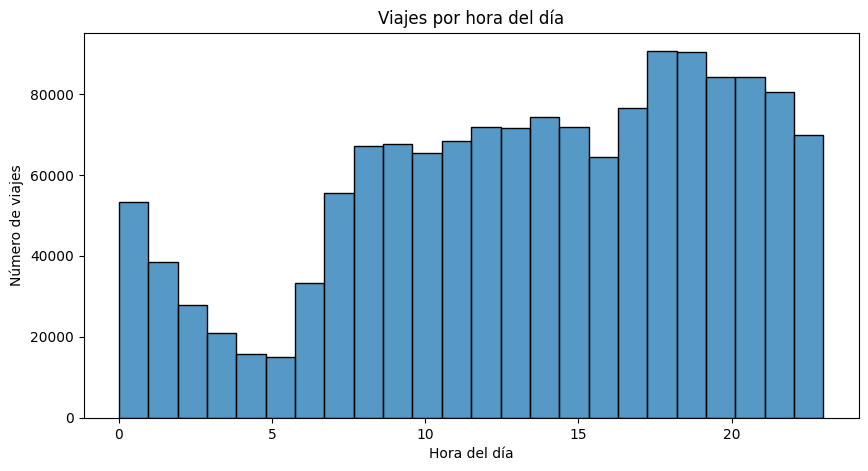

In [20]:
#Grafico 2:Viajes por hora del dia.
plt.figure(figsize=(10, 5))
sns.histplot(df['hora_recogida'], bins=24, kde=False)
plt.xlabel('Hora del día')
plt.ylabel('Número de viajes')
plt.title('Viajes por hora del día')
plt.show()

El gráfico muestra un alto número de viajes alrededor de la medianoche, seguido de una caída en la madrugada entre las 2 y 6 a.m., cuando la actividad es mínima. A partir de las 6 a.m., los viajes aumentan progresivamente, probablemente debido a desplazamientos matutinos. Se observa un segundo pico entre las 17 y 21 horas, lo que indica un incremento en la movilidad al final del día, posiblemente relacionado con la salida del trabajo y actividades recreativas.









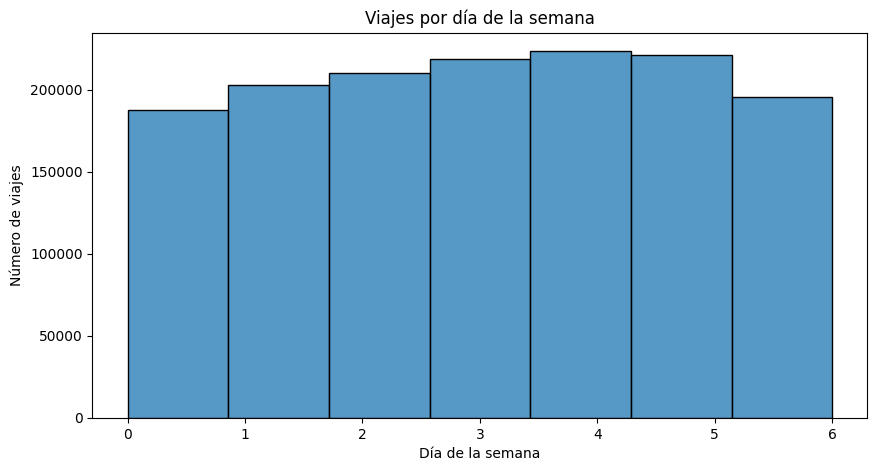

In [21]:
#Grafico 3:Viajes por día de la semana.

plt.figure(figsize=(10, 5))
sns.histplot(df['dia_semana_recogida'], bins=7, kde=False)
plt.xlabel('Día de la semana')
plt.ylabel('Número de viajes')
plt.title('Viajes por día de la semana')
plt.show()


El gráfico muestra que la cantidad de viajes varía a lo largo de la semana. Se observa un incremento progresivo desde el inicio de la semana, alcanzando su punto máximo entre el miércoles y el viernes. Durante el sábado y el domingo, la cantidad de viajes disminuye, lo que puede indicar una menor demanda de transporte en comparación con los días laborales.









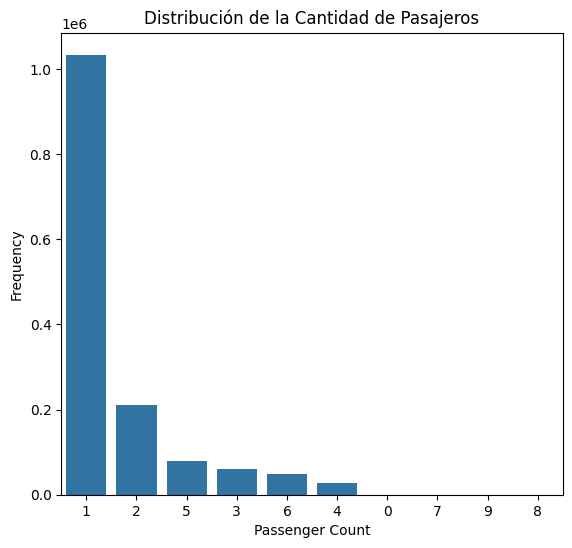

In [22]:
plt.figure(figsize=(22, 6))

# Passenger Count
plt.subplot(131)
sns.countplot(x=df['passenger_count'], order=df['passenger_count'].value_counts().index)
plt.xlabel('Passenger Count')
plt.ylabel('Frequency')
plt.title('Distribución de la Cantidad de Pasajeros')
plt.show()


La mayoría de los viajes tienen un solo pasajero, lo que sugiere un uso predominante de taxis para transporte individual.

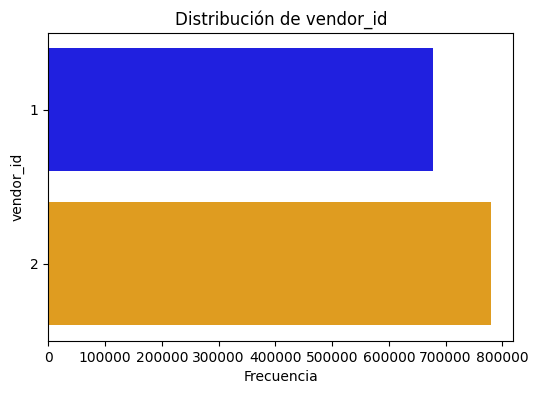

In [23]:
df['vendor_id'] = df['vendor_id'].astype(int)  # Asegurar que es entero

plt.figure(figsize=(6, 4))
sns.countplot(y=df['vendor_id'], hue=df['vendor_id'], palette={1: "blue", 2: "orange"}, legend=False)
plt.xlabel('Frecuencia')
plt.ylabel('vendor_id')
plt.title('Distribución de vendor_id')
plt.show()



Se observa que hay dos proveedores de servicio (1 y 2), con una diferencia notable en la cantidad de viajes. El proveedor 2 tiene más registros que el proveedor 1, lo que sugiere que tiene una mayor participación en los datos analizados. Esta diferencia podría influir en el análisis, por lo que sería útil investigar si existen variaciones en la calidad o el comportamiento de los viajes según el proveedor.

<ipython-input-24-843d6eac0414>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['store_and_fwd_flag'], palette={"0": "blue", "1": "orange"})


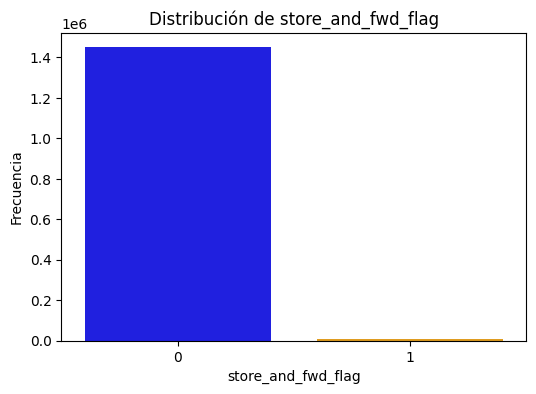

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['store_and_fwd_flag'], palette={"0": "blue", "1": "orange"})
plt.xlabel('store_and_fwd_flag')
plt.ylabel('Frecuencia')
plt.title('Distribución de store_and_fwd_flag')
plt.show()


La gran mayoría de los viajes tienen un valor de 0 (o "N"), lo que significa que fueron transmitidos en tiempo real sin necesidad de almacenamiento previo.

In [25]:
df.trip_duration.describe()

,trip_duration
count,1.458644e+06
mean,9.594923e+02
std,5.237432e+03
min,1.000000e+00
25%,3.970000e+02
50%,6.620000e+02
75%,1.075000e+03
max,3.526282e+06


Observando nuestra variable de estudio nos damos cuenta de cosas inusuales como viajes muy extremos que pueden ser errores, datos átipicos ó errores del sofware, esto puede ser preocupante en un futuro para los modelos.

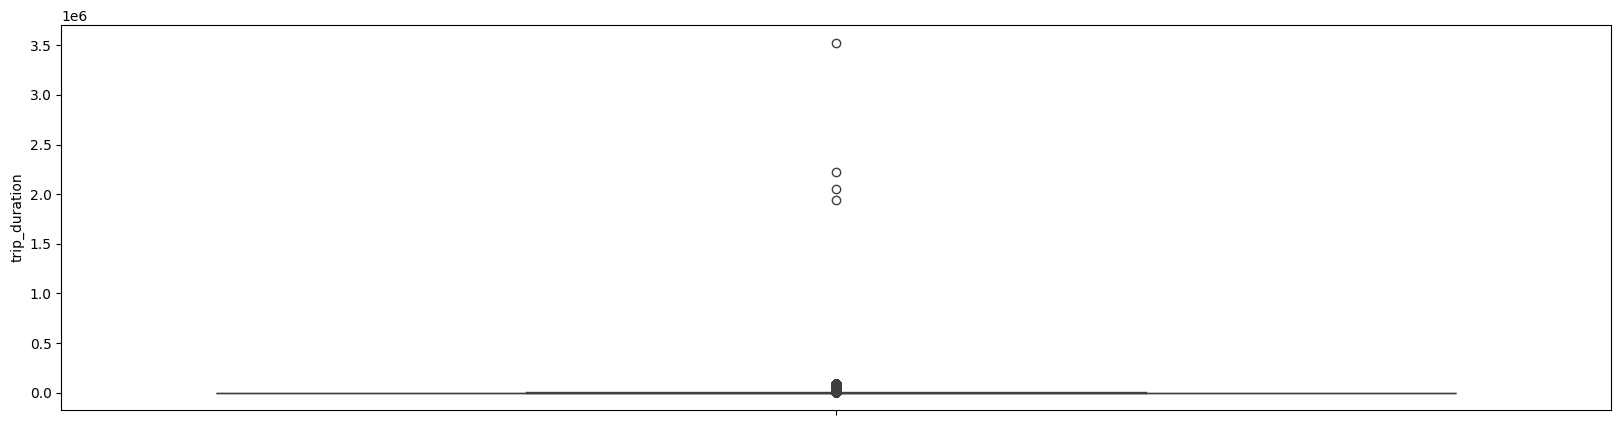

In [26]:
plt.figure(figsize = (20,5))
sns.boxplot(df.trip_duration)
plt.show()

La mayoría de los viajes duran menos de 20 minutos, con una mediana de 11 minutos. Sin embargo, hay valores atípicos extremos, como un viaje de más de 40 días, lo que genera una alta variabilidad en los datos. La desviación estándar es grande, indicando que las duraciones varían bastante.

In [27]:
df.trip_duration.groupby(pd.cut(df.trip_duration, np.arange(1,max(df.trip_duration),3600))).count()

<ipython-input-27-87bb8d946b7b>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.trip_duration.groupby(pd.cut(df.trip_duration, np.arange(1,max(df.trip_duration),3600))).count()


,trip_duration
trip_duration,
"(1, 3601]",1446313
"(3601, 7201]",10045
"(7201, 10801]",141
"(10801, 14401]",35
"(14401, 18001]",5
...,...
"(3506401, 3510001]",0
"(3510001, 3513601]",0
"(3513601, 3517201]",0


Hay algunos viajes con más de 24 horas de duración de viaje, es decir, 86400 segundos. Lo que podría haber ocurrido los fines de semana para los viajes fuera de la estación.
La mayor parte de los viajes se completan en un intervalo de 1 hora, con un buen número de viajes que superan la hora de duración.
Echemos un vistazo a esos viajes con una gran duración, estos son valores atípicos y deben eliminarse para mantener la coherencia de los datos.

In [28]:
df[df.trip_duration > 10800]

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,dia_recogida,hora_recogida,dia_semana_recogida,dia_llegada,hora_llegada,dia_semana_llegada
531,id3307903,2,2016-02-20 04:03:06,2016-02-21 03:33:00,3,-74.008102,40.741489,-74.009956,40.714611,0,84594,20,4,5,21,3,6
1134,id1091477,2,2016-05-07 18:36:22,2016-05-08 18:32:11,1,-73.990242,40.750919,-73.976280,40.750889,0,86149,7,18,5,8,18,6
1865,id3431345,2,2016-06-07 12:58:48,2016-06-08 12:58:00,6,-73.954956,40.777649,-73.981033,40.743713,0,86352,7,12,1,8,12,2
3442,id1487069,2,2016-02-13 00:21:49,2016-02-14 00:19:05,1,-73.968590,40.799217,-73.979584,40.784714,0,86236,13,0,5,14,0,6
4172,id3674870,2,2016-03-18 11:54:20,2016-03-19 11:34:17,1,-73.989090,40.736992,-73.972336,40.751511,0,85197,18,11,4,19,11,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455097,id2798196,2,2016-03-20 03:51:36,2016-03-21 00:00:00,2,-73.969299,40.757301,-73.870277,40.709808,0,72504,20,3,6,21,0,0
1456458,id2055880,2,2016-02-08 19:11:31,2016-02-09 19:08:44,3,-73.973282,40.760792,-73.988518,40.764210,0,86233,8,19,0,9,19,1
1457207,id1910950,2,2016-06-08 16:29:12,2016-06-09 16:11:03,1,-73.958061,40.800869,-73.964119,40.805515,0,85311,8,16,2,9,16,3
1457752,id1215198,2,2016-02-02 11:31:10,2016-02-03 11:29:44,6,-73.972069,40.794220,-73.961014,40.806728,0,86314,2,11,1,3,11,2



Estos viajes duraron más de 1 dia, lo que parece poco probable por la distancia recorrida.
Todos los viajes son realizados por el proveedor 1, lo que nos indica el hecho de que este proveedor podría permitir viajes mucho más largos para las estaciones remotas.
Todos estos viajes se realizan los martes del 1er mes o los sábados del 2º mes. Puede haber alguna relación con el día de la semana, el lugar de recogida, el mes y el pasajero.
Pero fallan en nuestro propósito de predicción correcta y traen inconsistencias en el cálculo del algoritmo.


In [29]:
df = df[df.trip_duration <= 7200]


Listo, ya hemos eliminado esos datos extremos tomando viajes de maximo 3 horas.




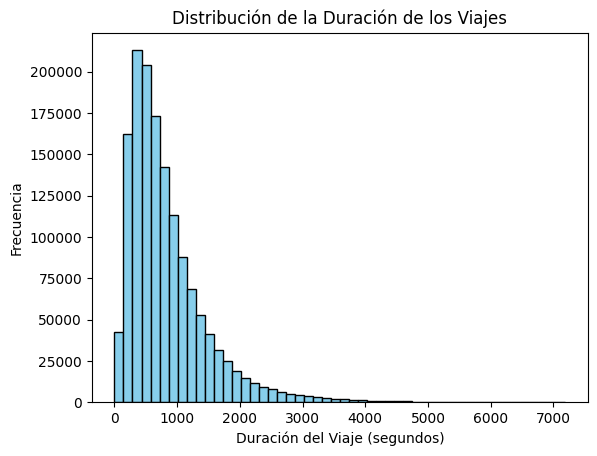

In [30]:
import matplotlib.pyplot as plt

# Crear un histograma de la columna 'trip_duration'
plt.hist(df['trip_duration'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de la Duración de los Viajes')
plt.xlabel('Duración del Viaje (segundos)')
plt.ylabel('Frecuencia')
plt.show()


<ipython-input-31-08e729c1e4d6>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.trip_duration.groupby(pd.cut(df.trip_duration, np.arange(1,7200,600))).count().plot(kind='barh')


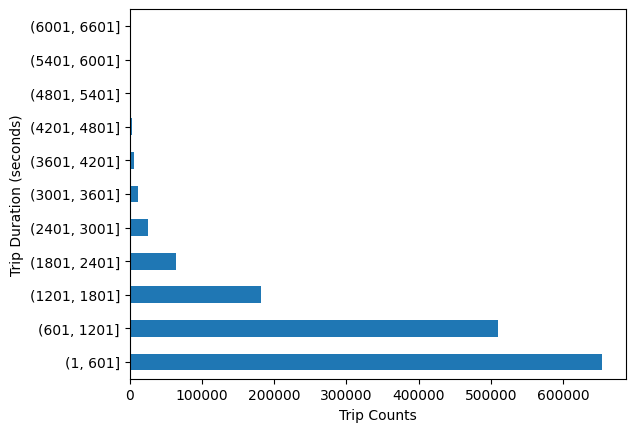

In [31]:
df.trip_duration.groupby(pd.cut(df.trip_duration, np.arange(1,7200,600))).count().plot(kind='barh')
plt.xlabel('Trip Counts')
plt.ylabel('Trip Duration (seconds)')
plt.show()

Podemos observar que la mayoría de los viajes tardaron de 0 a 30 minutos en completarse, es decir, aproximadamente 1800 segundos. Pasemos a la siguiente característica.

ANALISIS BIVARIADO

In [32]:
df.shape

(1456391, 17)

In [33]:
df.columns


Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'dia_recogida', 'hora_recogida', 'dia_semana_recogida',
       'dia_llegada', 'hora_llegada', 'dia_semana_llegada'],
      dtype='object')

In [34]:
df_info=df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1456391 entries, 0 to 1458643
Data columns (total 17 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   id                   1456391 non-null  object        
 1   vendor_id            1456391 non-null  int64         
 2   pickup_datetime      1456391 non-null  datetime64[ns]
 3   dropoff_datetime     1456391 non-null  datetime64[ns]
 4   passenger_count      1456391 non-null  int64         
 5   pickup_longitude     1456391 non-null  float64       
 6   pickup_latitude      1456391 non-null  float64       
 7   dropoff_longitude    1456391 non-null  float64       
 8   dropoff_latitude     1456391 non-null  float64       
 9   store_and_fwd_flag   1456391 non-null  category      
 10  trip_duration        1456391 non-null  int64         
 11  dia_recogida         1456391 non-null  int32         
 12  hora_recogida        1456391 non-null  int32         
 13  di

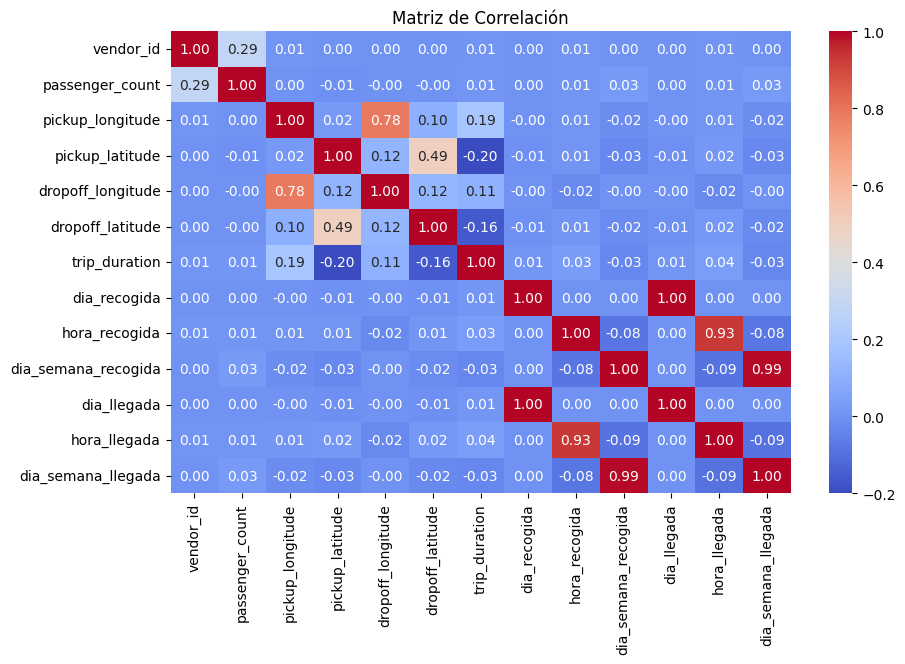

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar solo columnas numéricas
numeric_cols = df.select_dtypes(include=["number"])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()


La matriz de correlación muestra las relaciones entre las variables del dataset, indicando qué tan fuertemente están asociadas entre sí. Se observa una alta correlación entre las variables relacionadas con el tiempo, como el día de recogida y día de llegada (0.99) y el día de la semana de recogida y llegada (0.99), lo cual es esperado, ya que la mayoría de los viajes ocurren dentro del mismo día.

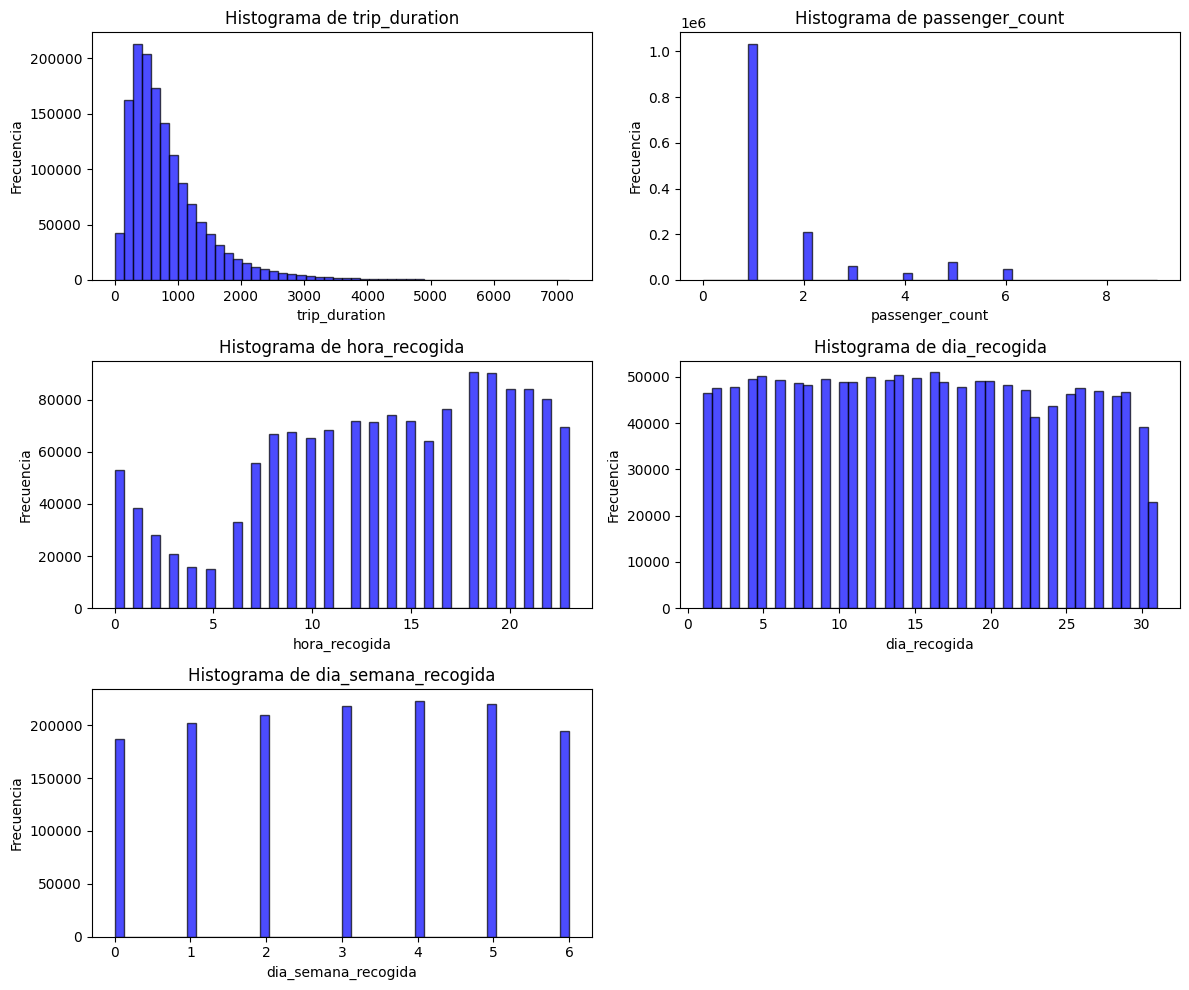

In [36]:
# Lista de características que parecen ser relevantes según la matriz de correlación
features = ['trip_duration', 'passenger_count',
            'hora_recogida', 'dia_recogida', 'dia_semana_recogida']

plt.figure(figsize=(12, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)
    plt.hist(df[feature], bins=50, color='blue', alpha=0.7, edgecolor='black')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')
    plt.title(f'Histograma de {feature}')

plt.tight_layout()
plt.show()

El análisis de los histogramas revela que la variable log_trip_duration, que es la versión transformada de la duración del viaje, sigue aproximadamente una distribución normal, lo cual es beneficioso para modelos estadísticos que asumen normalidad en la variable objetivo.

Latitud y longitud

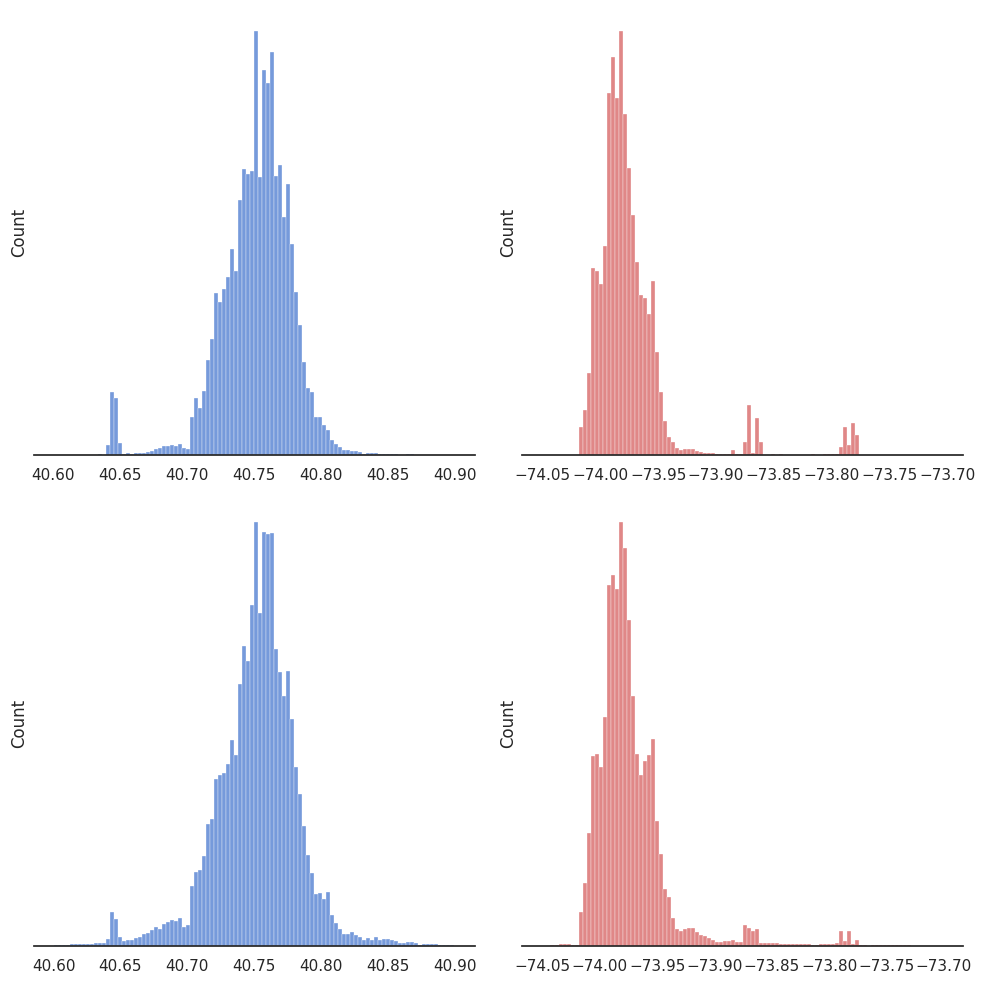

In [37]:
# Filtrar solo viajes dentro de Nueva York
df = df.loc[(df.pickup_latitude > 40.6) & (df.pickup_latitude < 40.9)]
df = df.loc[(df.dropoff_latitude > 40.6) & (df.dropoff_latitude < 40.9)]
df = df.loc[(df.dropoff_longitude > -74.05) & (df.dropoff_longitude < -73.7)]
df = df.loc[(df.pickup_longitude > -74.05) & (df.pickup_longitude < -73.7)]

# Crear una copia del DataFrame filtrado
df_filtered = df.copy()

# Configuración de estilo para los gráficos
sns.set(style="white", palette="muted", color_codes=True)

# Crear subgráficos (2x2)
f, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=False, sharey=False)
sns.despine(left=True)

# Histogramas de coordenadas
sns.histplot(df_filtered['pickup_latitude'].values, label='pickup_latitude', color="b", bins=100, ax=axes[0, 0])
sns.histplot(df_filtered['pickup_longitude'].values, label='pickup_longitude', color="r", bins=100, ax=axes[0, 1])
sns.histplot(df_filtered['dropoff_latitude'].values, label='dropoff_latitude', color="b", bins=100, ax=axes[1, 0])
sns.histplot(df_filtered['dropoff_longitude'].values, label='dropoff_longitude', color="r", bins=100, ax=axes[1, 1])

# Ajustes finales
plt.setp(axes, yticks=[])
plt.tight_layout()
plt.show()

Se observan picos alrededor de 40.75° de latitud y -73.95° de longitud, lo que sugiere que la mayoría de los viajes inician y terminan en ubicaciones centrales de Nueva York, posiblemente en Manhattan.

#Mejoras para el EDA

In [38]:
print("No. de filas en el conjunto de entrenamiento:", df.shape[0])
print("No. de columnas en el conjunto de entrenamiento:", df.shape[1])


No. de filas en el conjunto de entrenamiento: 1450163
No. de columnas en el conjunto de entrenamiento: 17


#Creación de la variable distancia en km.

In [39]:
from math import radians, sin, cos, sqrt, atan2

# Función para calcular la distancia Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])  # Convertir a radianes
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c  # Distancia en km

# Aplicar la función a los datos
df['distance_km'] = df.apply(lambda row: haversine(row['pickup_latitude'], row['pickup_longitude'],
                                                               row['dropoff_latitude'], row['dropoff_longitude']), axis=1)


Tranformando las variables para el test:

In [40]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,dia_recogida,hora_recogida,dia_semana_recogida,dia_llegada,hora_llegada,dia_semana_llegada,distance_km
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,0,455,14,17,0,14,17,0,1.498521
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,0,663,12,0,6,12,0,6,1.805507
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,19,11,1,19,12,1,6.385098
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,0,429,6,19,2,6,19,2,1.485498
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,0,435,26,13,5,26,13,5,1.188588


Se tomó la longitud y la latitud para tener en cuanta la distancia en km y se agregó a los conjuntos de datos.

In [41]:
df['distance_km'].describe()


,distance_km
count,1.450163e+06
mean,3.373767e+00
std,3.783165e+00
min,0.000000e+00
25%,1.229910e+00
50%,2.085612e+00
75%,3.839279e+00
max,3.308128e+01


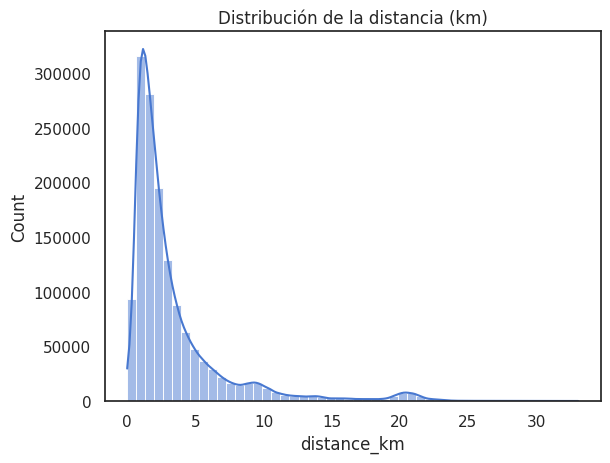

In [42]:
sns.histplot(df['distance_km'], bins=50, kde=True)
plt.title("Distribución de la distancia (km)")
plt.show()


La distribución de la variable distance_km muestra que la mayoría de los viajes son cortos, entre 0 y 5 km, con una disminución progresiva a medida que la distancia aumenta. Existen algunos picos en distancias mayores, lo que podría indicar rutas comunes o viajes atípicos. Además, hay registros con distance_km = 0, lo que sugiere posibles errores o datos inconsistentes que podrían afectar el modelo.

In [43]:
print(df[df["distance_km"] == 0].shape[0])
df = df[df["distance_km"] > 0]


5564


Los viajes con distancia igul a cero se filtraron y se eliminaron, debido a que podrian ser un error, tiempo de espera de los pasajeros y correspondian al 0.38% de nuestros datos.

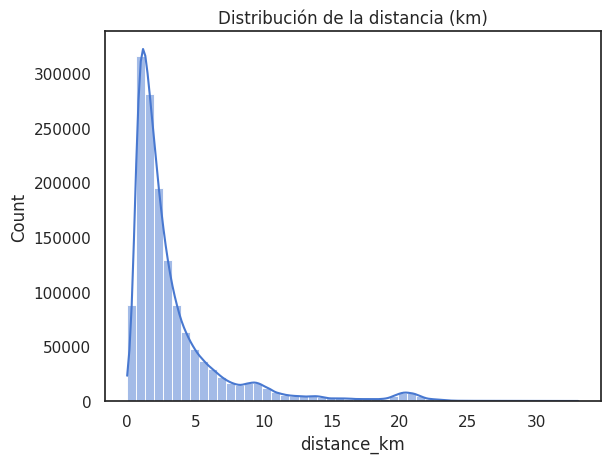

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['distance_km'], bins=50, kde=True)
plt.title("Distribución de la distancia (km)")
plt.show()

Los datos registrados con distancia igual a 0 equivalen al 0.38% de nuestros datos, por esta razón fueron imputados para un mejor rendimiento en los modelos.

Se tendrá en cuenta todo lo anterior para verificar las variables que explicarian mejor nuestra variable de estudio.

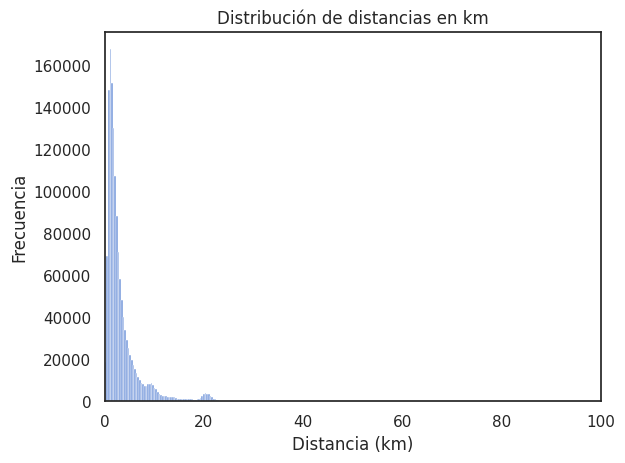

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['distance_km'], bins=100)
plt.xlim(0, 100)  # Para ver solo el rango razonable
plt.title('Distribución de distancias en km')
plt.xlabel('Distancia (km)')
plt.ylabel('Frecuencia')
plt.show()


In [46]:
print("No. of rows: ", df.shape[0])
print("No. of columns: ", df.shape[1])

No. of rows:  1444599
No. of columns:  18


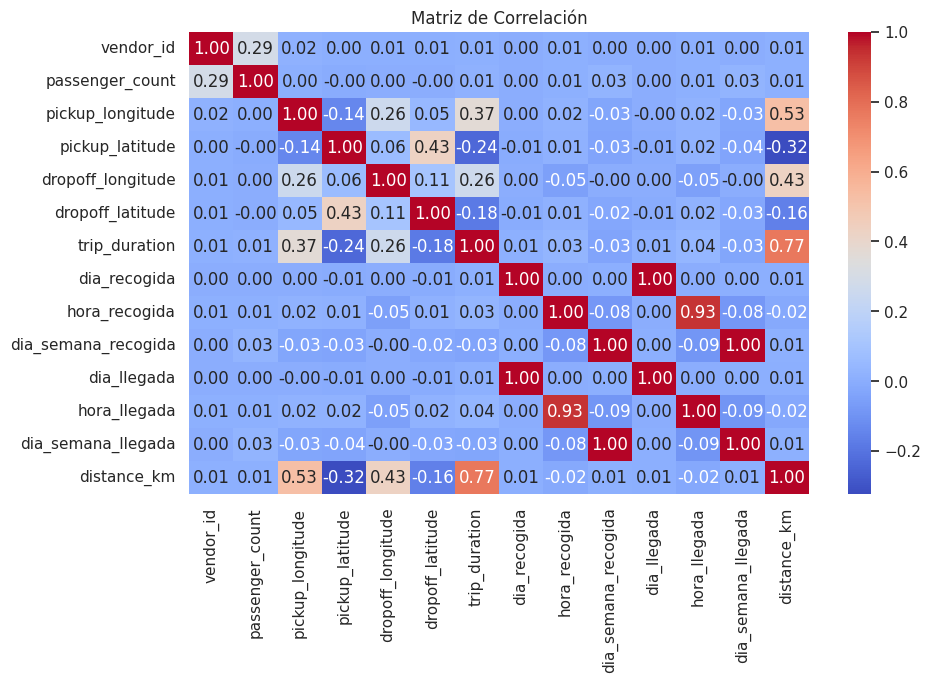

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar solo columnas numéricas
numeric_cols = df.select_dtypes(include=["number"])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()



In [48]:
print(df.columns)



Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'dia_recogida', 'hora_recogida', 'dia_semana_recogida',
       'dia_llegada', 'hora_llegada', 'dia_semana_llegada', 'distance_km'],
      dtype='object')


In [49]:
print(df.shape)


(1444599, 18)


FEATURES

Para un mejor manejo de nuestras variables y mejores resultados en nuestros modelos para predecir el tiempo de viaje se crearan nuevas features espacio-temporales en base a la latitud, longitus, horas de salida y horas de llegada

In [50]:
from sklearn.cluster import KMeans


 Creamos variables categóricas geoespaciales agrupando ubicaciones similares mediante KMeans.
 Esto permite representar zonas de recogida y destino como clusters numéricos,
 facilitando al modelo identificar patrones espacio-temporales en los trayectos de taxi.


In [51]:
n_clusters = 20

# Pickup clustering
pickup_coords = df[['pickup_latitude', 'pickup_longitude']].to_numpy()
kmeans_pickup = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['pickup_cluster'] = kmeans_pickup.fit_predict(pickup_coords)

# Dropoff clustering
dropoff_coords = df[['dropoff_latitude', 'dropoff_longitude']].to_numpy()
kmeans_dropoff = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['dropoff_cluster'] = kmeans_dropoff.fit_predict(dropoff_coords)


In [52]:
#  Paso 1: Crear el grupo combinado pickup+dropoff
df['location_group'] = df['pickup_cluster'].astype(str) + "_" + df['dropoff_cluster'].astype(str)


In [53]:
df[['pickup_cluster', 'dropoff_cluster',"location_group"]].head()


,pickup_cluster,dropoff_cluster,location_group
0,12,4,12_4
1,15,10,15_10
2,12,13,12_13
3,9,13,9_13
4,7,19,7_19


pickup_cluster: identifica la zona de recogida.

dropoff_cluster: identifica la zona de destino.

In [54]:
import plotly.express as px

sample_df = df.sample(5000, random_state=42)

fig = px.scatter_mapbox(
    sample_df,
    lat="pickup_latitude",
    lon="pickup_longitude",
    color="pickup_cluster",
    zoom=10,
    mapbox_style="carto-positron",
    title="Pickup Clusters NYC"
)

fig.show()


Creamos otra feature en base a la anterior para el tiempo de viaje promedio entre las zonas divividas por los clusters.

In [55]:
df['pickup_zone_hour'] = df['pickup_cluster'].astype(str) + '_' + df['hora_recogida'].astype(str)
mean_duration = df.groupby('pickup_zone_hour')['trip_duration'].mean().to_dict()
df['mean_duration_cluster'] = df['pickup_zone_hour'].map(mean_duration)


In [56]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,dia_semana_recogida,dia_llegada,hora_llegada,dia_semana_llegada,distance_km,pickup_cluster,dropoff_cluster,location_group,pickup_zone_hour,mean_duration_cluster
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,0,...,0,14,17,0,1.498521,12,4,12_4,12_17,913.559231
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,0,...,6,12,0,6,1.805507,15,10,15_10,15_0,719.865498
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,0,...,1,19,12,1,6.385098,12,13,12_13,12_11,880.833922
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,0,...,2,6,19,2,1.485498,9,13,9_13,9_19,894.712372
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,0,...,5,26,13,5,1.188588,7,19,7_19,7_13,701.873442


##MODELOS Y RESULTADOS

*   Linear Regression
*   Ridge
*   Lasso
*   KNN
*   Random forest
*   XGboost
*   SVR

In [61]:
# División de los datos
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.diagnostic import acorr_ljungbox, normal_ad
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, LinearSVR
from xgboost import XGBRegressor
import joblib, os, time
import numpy as np
import pandas as pd

# Variables predictoras y variable objetivo
features = ['passenger_count','distance_km','pickup_cluster','dropoff_cluster',
            'mean_duration_cluster', 'hora_recogida','dia_semana_recogida', 'hora_llegada','dia_semana_llegada']
X = df[features]
y = df['trip_duration']

# División en entrenamiento y prueba (80/20 aleatorio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Conjunto de entrenamiento: X_train {X_train.shape}, y_train {y_train.shape}')
print(f'Conjunto de prueba: X_test {X_test.shape}, y_test {y_test.shape}')

# Definición de modelos y grids
models = {
    "Linear Regression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {'regressor__alpha': [0.1, 1, 10]}),
    "Lasso": (Lasso(), {'regressor__alpha': [0.01, 0.1, 1]}),
    "KNN": (KNeighborsRegressor(), {'regressor__n_neighbors': [3, 5, 7]}),
    "Random Forest": (RandomForestRegressor(random_state=42), {
        'regressor__n_estimators': [50, 100],
        'regressor__max_depth': [10, 20]
    }),
    "XGBoost": (XGBRegressor(random_state=42, n_jobs=-1), {
        'regressor__n_estimators': [50, 100],
        'regressor__max_depth': [3, 5]
    }),
    "LinearSVR": (LinearSVR(max_iter=1000), {
        'regressor__C': [0.1, 1, 10],
        'regressor__max_iter': [1000, 2000]
    }),
}

# K-Fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, (model, param_grid) in models.items():
    print(f"\n🔷 {name}")

    model_filename = f"{name.lower().replace(' ', '_')}.pkl"
    model_path = f'modelos/{model_filename}'

    if os.path.exists(model_path):
        best_model = joblib.load(model_path)
    else:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', model)
        ])

        grid = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)
        start = time.time()
        print(f"Entrenando {name}...")
        grid.fit(X_train, y_train)
        elapsed = time.time() - start

        best_model = grid.best_estimator_
        print(f"→ Mejor RMSE CV: {-grid.best_score_:.2f}")
        print(f"→ Mejor hiperparámetro: {grid.best_params_}")
        print(f"  Tiempo CPU: {elapsed:.2f} s")

        os.makedirs('modelos', exist_ok=True)
        joblib.dump(best_model, model_path)

    # Evaluación en test
    y_pred = best_model.predict(X_test)
    residuals = y_test - y_pred

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    ljung_pvalue = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]
    jb_stat, jb_pvalue = normal_ad(residuals)

    print(f"→ MAPE: {mape:.4f}")
    print(f"→ RMSE: {rmse:.2f}")
    print(f"→ R²: {r2:.4f}")
    print(f"→ Ljung-Box p: {ljung_pvalue:.4f}")
    print(f"→ Jarque-Bera p: {jb_pvalue:.4f}")

    results.append({
        'Modelo': name,
        'MAPE': mape,
        'RMSE': rmse,
        'R2': r2,
        'Ljung-Box p': ljung_pvalue,
        'Jarque-Bera p': jb_pvalue
    })

# Resumen de resultados
df_resultados = pd.DataFrame(results)
display(df_resultados)


Conjunto de entrenamiento: X_train (1155679, 9), y_train (1155679,)
Conjunto de prueba: X_test (288920, 9), y_test (288920,)

🔷 Linear Regression
→ MAPE: 0.5744
→ RMSE: 375.96
→ R²: 0.6603
→ Ljung-Box p: 0.5855
→ Jarque-Bera p: 0.0000

🔷 Ridge
→ MAPE: 0.5743
→ RMSE: 375.96
→ R²: 0.6603
→ Ljung-Box p: 0.5850
→ Jarque-Bera p: 0.0000

🔷 Lasso
→ MAPE: 0.5735
→ RMSE: 376.02
→ R²: 0.6601
→ Ljung-Box p: 0.5861
→ Jarque-Bera p: 0.0000

🔷 KNN
Entrenando KNN...
→ Mejor RMSE CV: 327.69
→ Mejor hiperparámetro: {'regressor__n_neighbors': 7}
  Tiempo CPU: 81.20 s
→ MAPE: 0.4136
→ RMSE: 327.02
→ R²: 0.7430
→ Ljung-Box p: 0.6721
→ Jarque-Bera p: 0.0000

🔷 Random Forest
Entrenando Random Forest...
→ Mejor RMSE CV: 305.33
→ Mejor hiperparámetro: {'regressor__max_depth': 20, 'regressor__n_estimators': 100}
  Tiempo CPU: 1722.74 s
→ MAPE: 0.3773
→ RMSE: 305.05
→ R²: 0.7763
→ Ljung-Box p: 0.3140
→ Jarque-Bera p: 0.0000

🔷 XGBoost
Entrenando XGBoost...
→ Mejor RMSE CV: 295.93
→ Mejor hiperparámetro: {'regre

,Modelo,MAPE,RMSE,R2,Ljung-Box p,Jarque-Bera p
0,Linear Regression,0.574368,375.961954,0.660255,0.585471,0.0
1,Ridge,0.574276,375.962730,0.660254,0.584969,0.0
2,Lasso,0.573513,376.022847,0.660145,0.586076,0.0
3,KNN,0.413592,327.017291,0.742956,0.672123,0.0
4,Random Forest,0.377269,305.047118,0.776334,0.314016,0.0
5,XGBoost,0.382780,297.265467,0.787600,0.498951,0.0
6,LinearSVR,0.509735,415.203422,0.585631,0.251595,0.0


#Incorporación de Clustering para Variables Geográficas

- Se creó una representación de las ubicaciones de recogida y entrega mediante clusters (pickup_cluster y dropoff_cluster) usando KMeans con 20 clusters.

- Esto permitió capturar patrones espaciales relevantes para la duración del viaje sin usar las coordenadas exactas, que pueden ser demasiado granulares.

**Creación de un Grupo Combinado para Validación**

- Se combinó pickup_cluster y dropoff_cluster en una nueva variable location_group para representar de manera única cada par de ubicaciones.

- Esta variable se usó para definir grupos en la validación cruzada, garantizando que el modelo no vea datos de la misma ubicación (pickup-dropoff) simultáneamente en entrenamiento y validación, evitando data leakage geográfico.

- Uso de GroupKFold para Validación Cruzada con Grupos de Ubicación

- En lugar de una validación aleatoria tradicional (KFold) o por tiempo (TimeSeriesSplit), se implementó GroupKFold usando la variable location_group.
Esto asegura que la validación sea más realista, simulando el desempeño del modelo en ubicaciones no vistas anteriormente.

- Mantenimiento de pickup_cluster y dropoff_cluster como Features en el Modelo.Aunque se usaron para formar los grupos de validación, estas variables también se conservaron en el conjunto de features para que el modelo pueda aprovechar la información espacial en la predicción.

Se puede obser


📊 Procesando modelo: Linear Regression


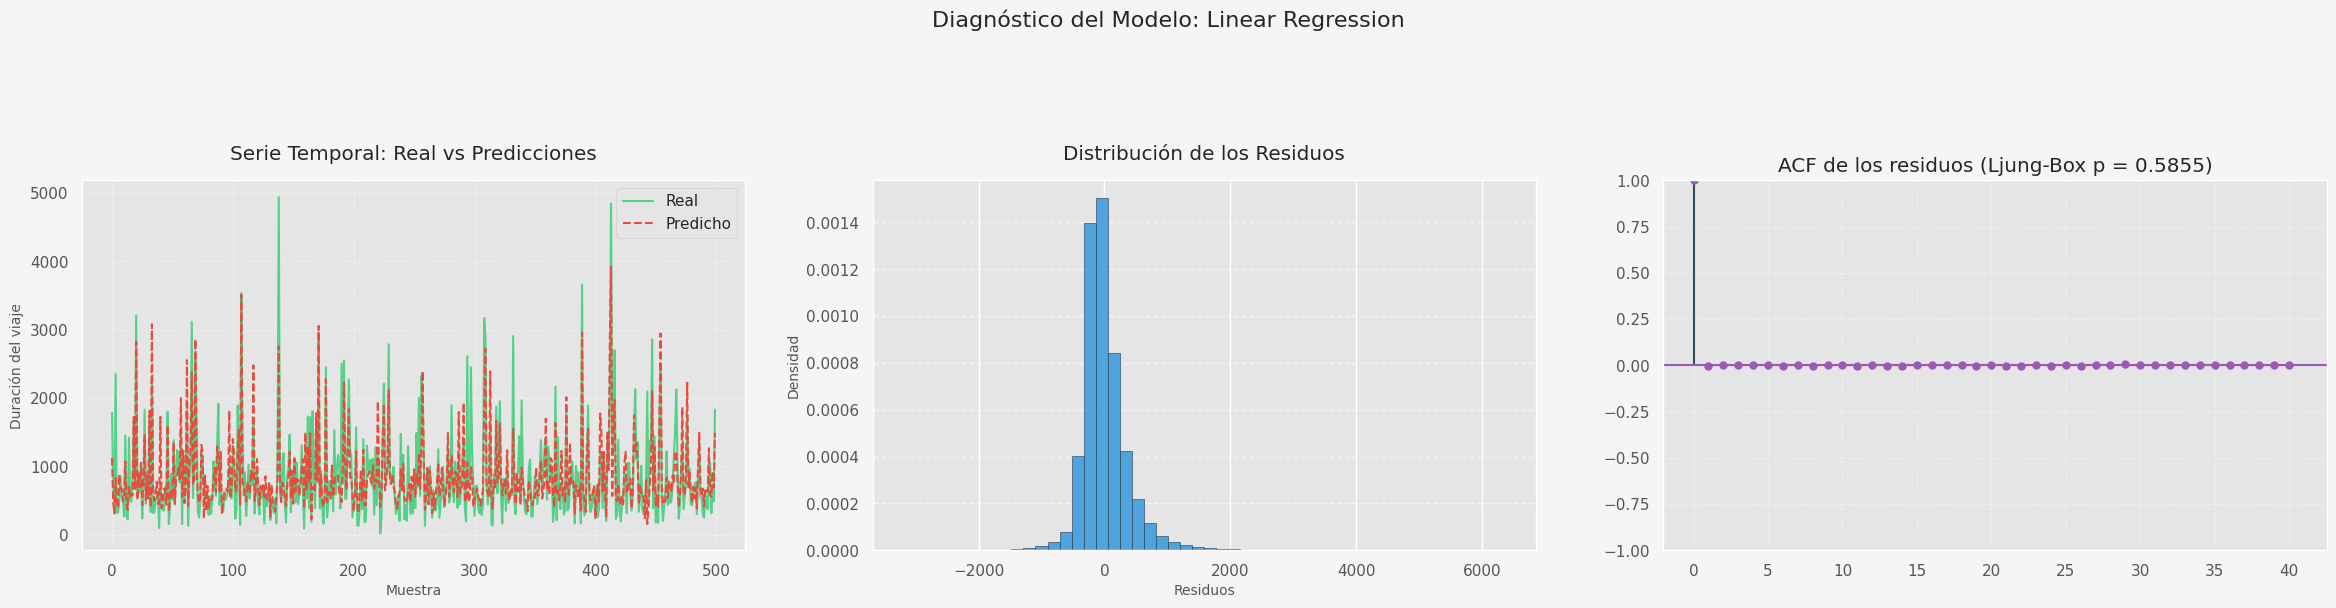

✅ Gráficas generadas para: Linear Regression
--------------------------------------------------

📊 Procesando modelo: Ridge


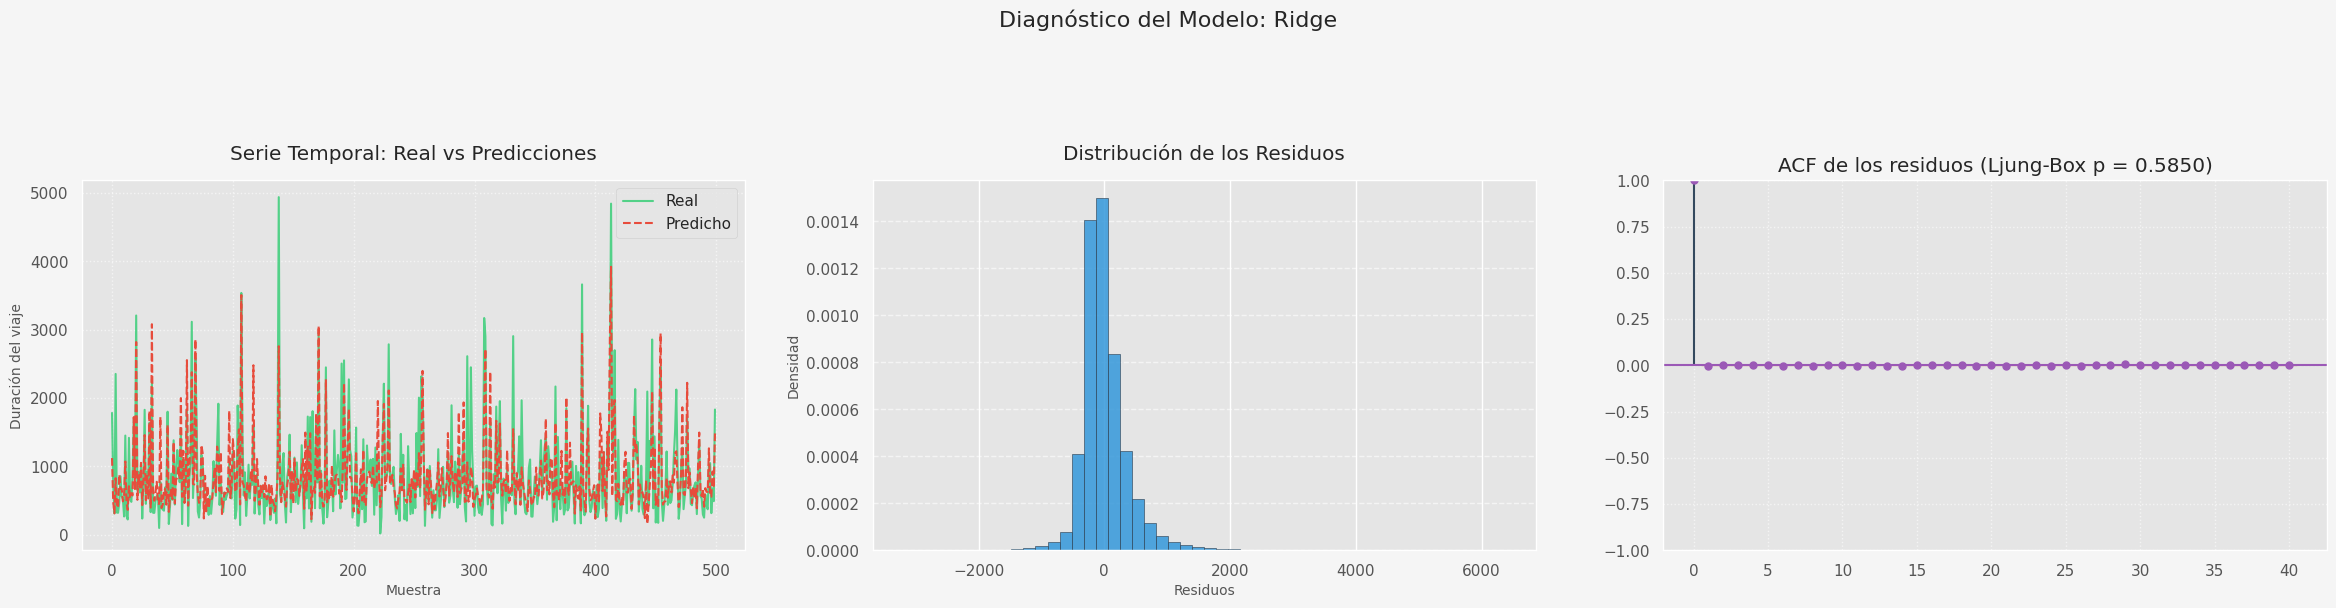

✅ Gráficas generadas para: Ridge
--------------------------------------------------

📊 Procesando modelo: Lasso


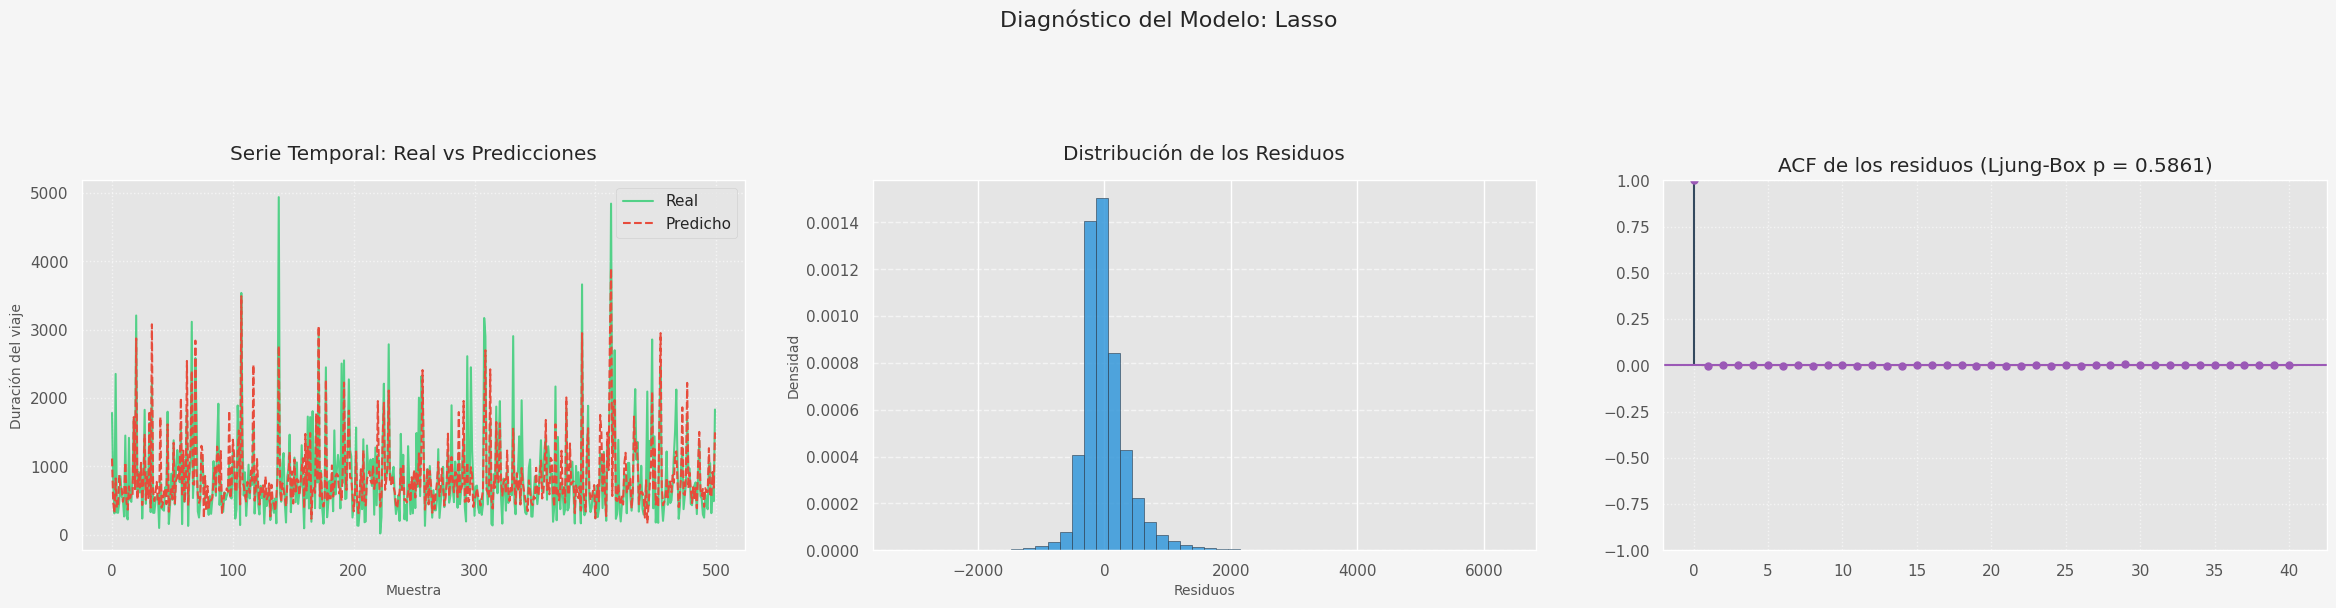

✅ Gráficas generadas para: Lasso
--------------------------------------------------

📊 Procesando modelo: KNN


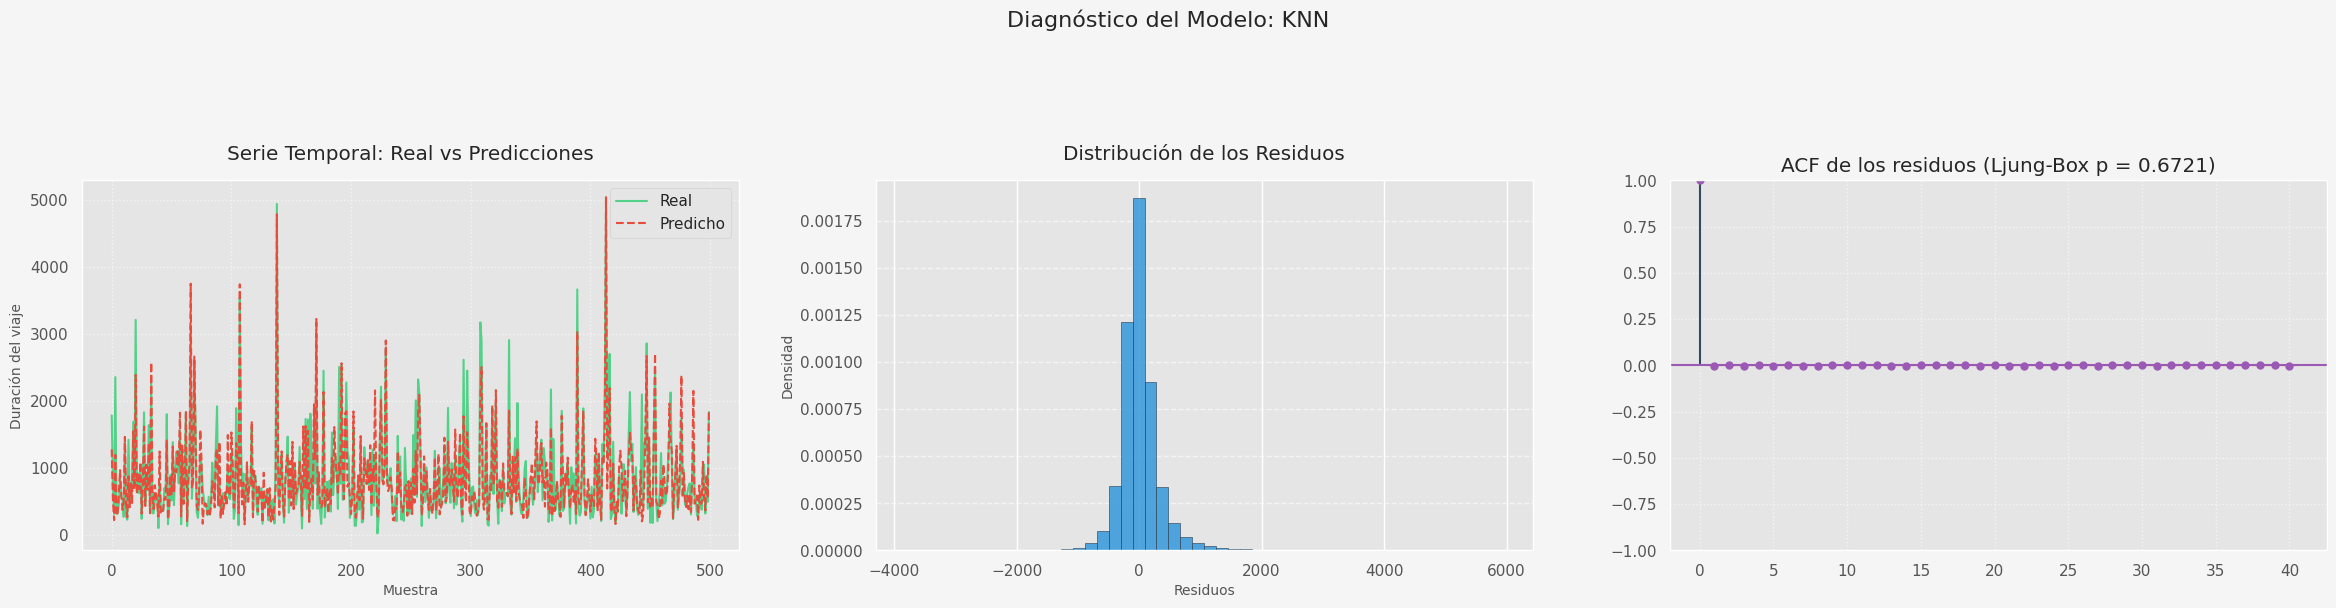

✅ Gráficas generadas para: KNN
--------------------------------------------------

📊 Procesando modelo: Random Forest


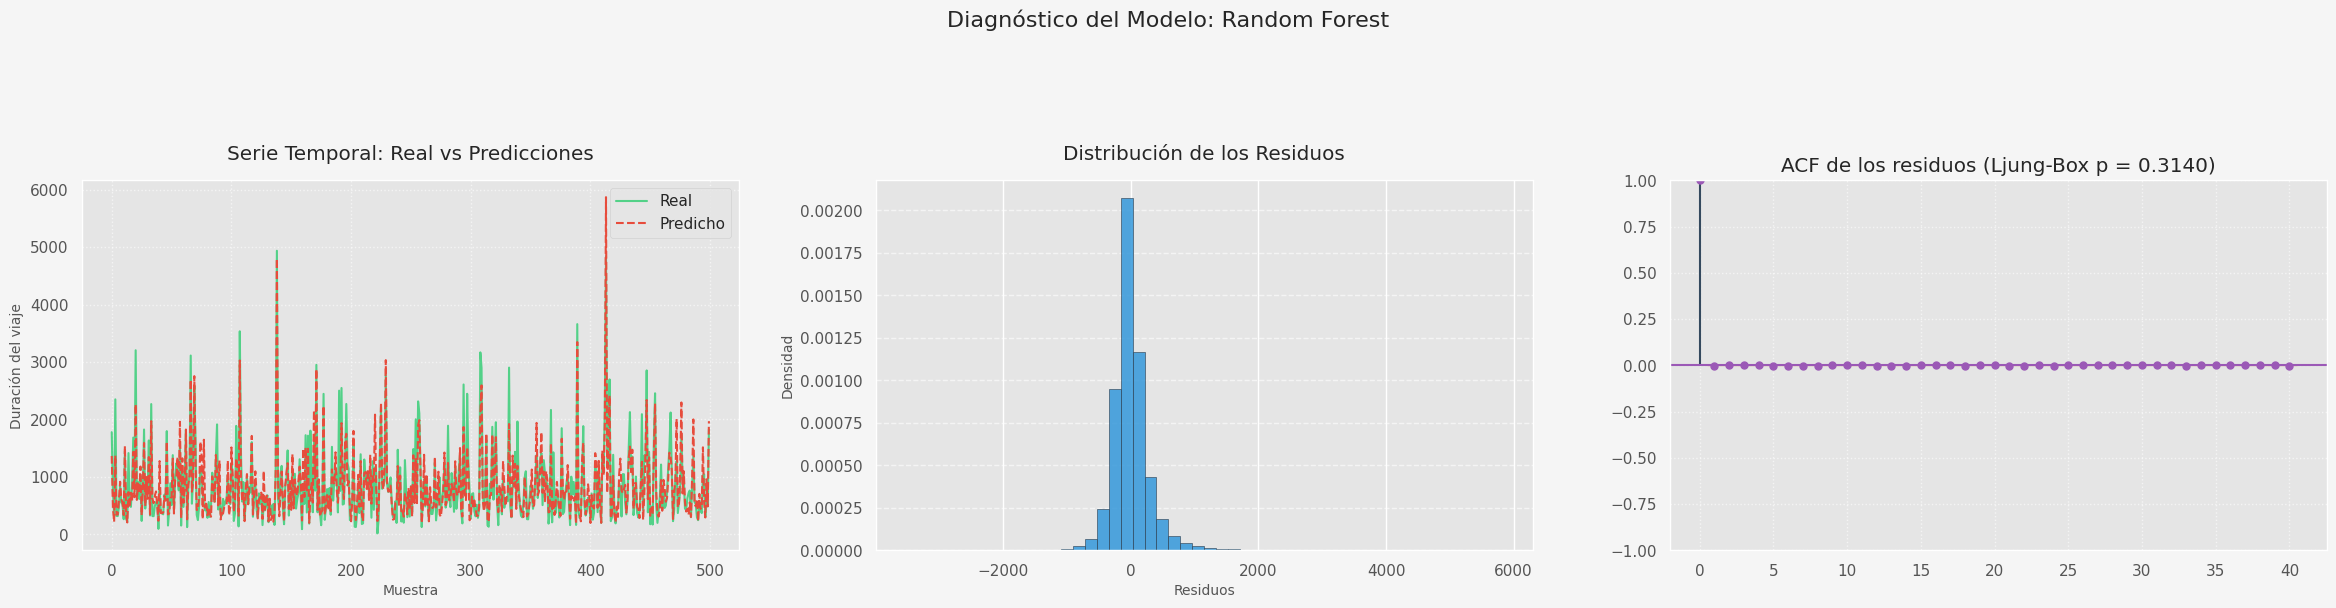

✅ Gráficas generadas para: Random Forest
--------------------------------------------------

📊 Procesando modelo: XGBoost


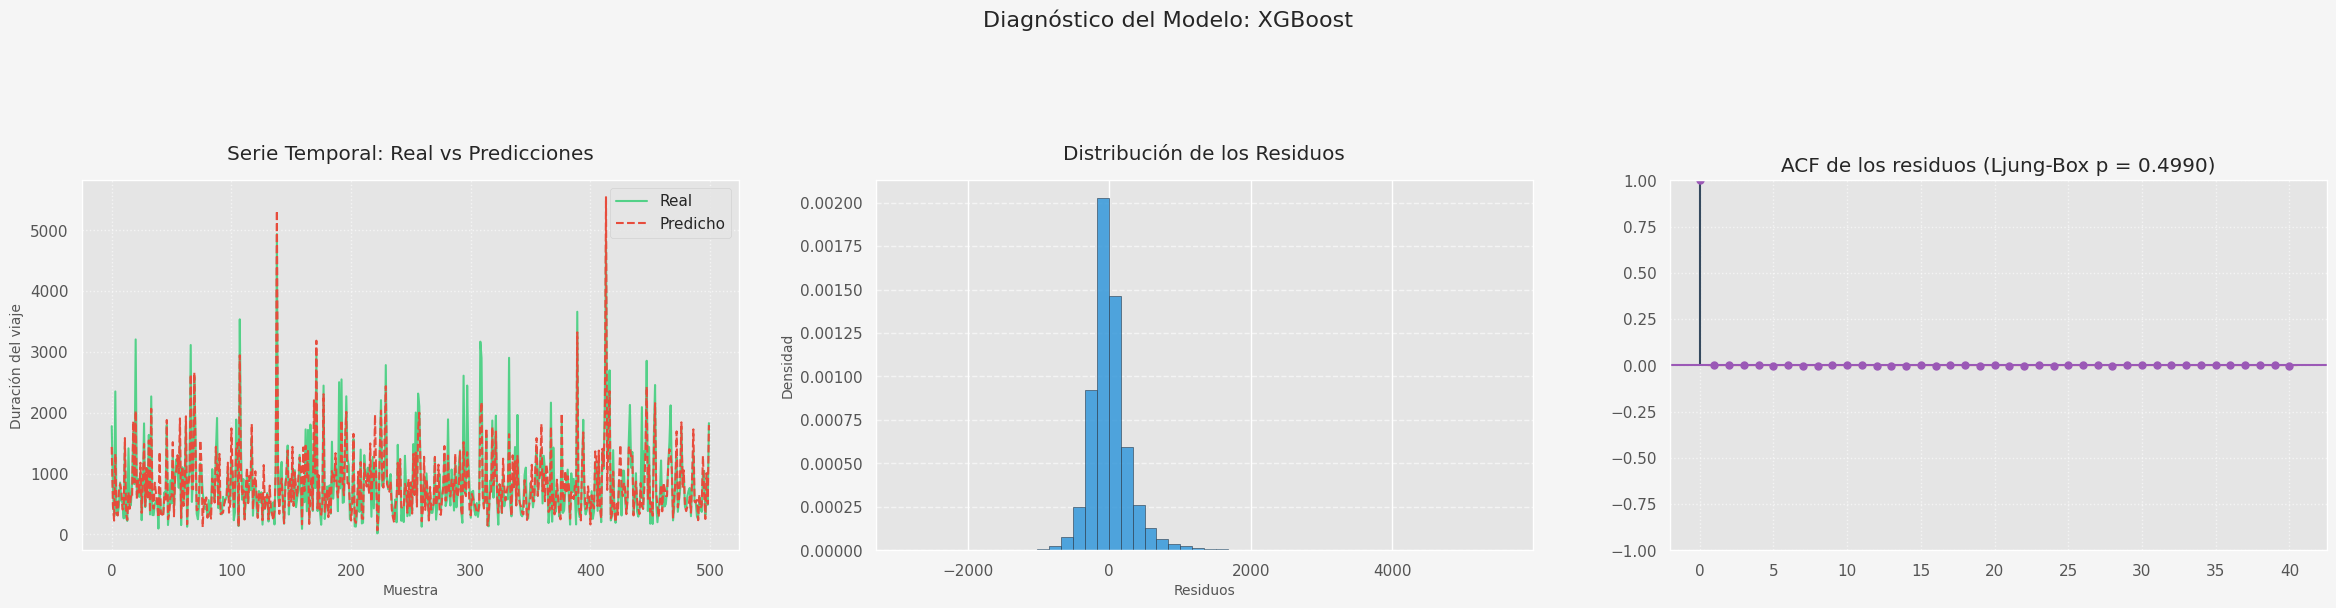

✅ Gráficas generadas para: XGBoost
--------------------------------------------------

📊 Procesando modelo: LinearSVR


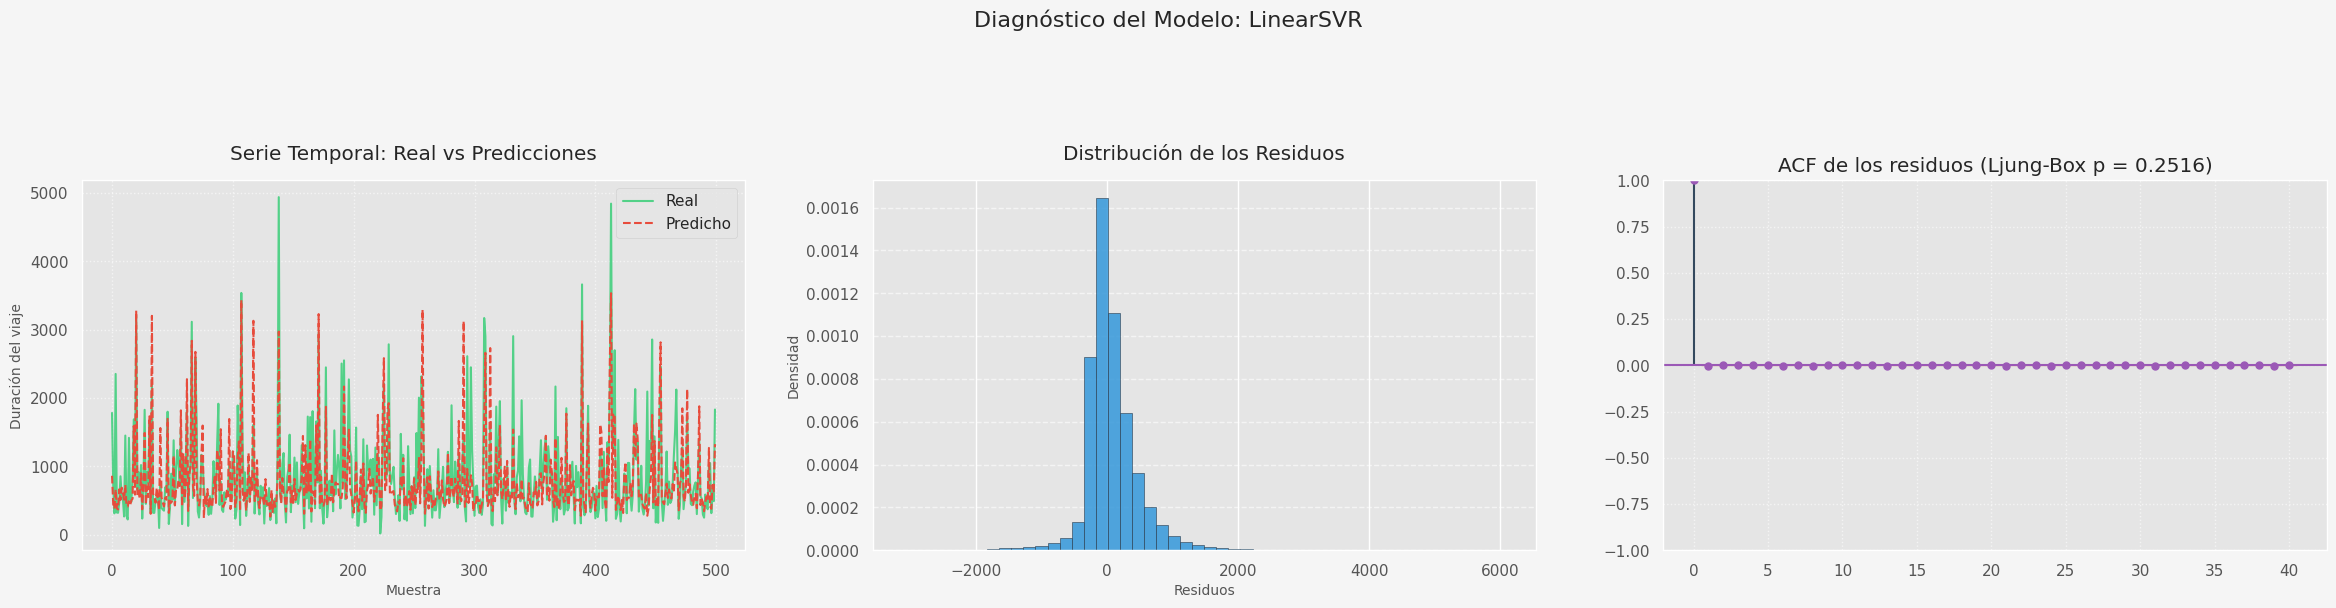

✅ Gráficas generadas para: LinearSVR
--------------------------------------------------


In [62]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import seaborn as sns
# Configuración global de estilos
plt.style.use('ggplot')
plt.rcParams['figure.dpi'] = 100  # Ajusta según tu pantalla
%matplotlib inline

# Asumiendo que ya tienes:
# - df_resultados (DataFrame con modelos)
# - X_test, y_test (datos de prueba)
# - results (datos originales si es necesario)

for name in df_resultados['Modelo']:
    print(f"\n📊 Procesando modelo: {name}")

    # 1. Cargar modelo entrenado
    model_filename = f"{name.lower().replace(' ', '_')}.pkl"
    model_path = f'modelos/{model_filename}'
    best_model = joblib.load(model_path)

    # 2. Calcular predicciones y residuos
    y_pred_test = best_model.predict(X_test)
    residuals = y_test - y_pred_test

    # 3. Crear figura con 3 subgráficas
    fig = plt.figure(figsize=(24, 6), facecolor='#f5f5f5')  # Fondo claro
    fig.suptitle(f'Diagnóstico del Modelo: {name}', fontsize=16, y=1.05)

    # ----------------------------------------------------------
    # Gráfica 1: Comparación real vs predicho
    # ----------------------------------------------------------
    ax1 = plt.subplot(1, 3, 1)
    sample_size = min(500, len(y_test))
    sample_indices = np.linspace(0, len(y_test)-1, sample_size, dtype=int)

    ax1.plot(y_test.iloc[sample_indices].values,
            color='#2ecc71',
            label='Real',
            linewidth=1.5,
            alpha=0.8)

    ax1.plot(y_pred_test[sample_indices],
            color='#e74c3c',
            linestyle='--',
            label='Predicho',
            linewidth=1.5)

    ax1.set_xlabel('Muestra', fontsize=10)
    ax1.set_ylabel('Duración del viaje', fontsize=10)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.set_title('Serie Temporal: Real vs Predicciones', pad=15)

    # ----------------------------------------------------------
    # Gráfica 2: Histograma de residuos
    # ----------------------------------------------------------
    ax2 = plt.subplot(1, 3, 2)
    n_bins = min(50, len(residuals)//10)  # Bins adaptativos
    ax2.hist(residuals,
            bins=n_bins,
            color='#3498db',
            edgecolor='#2c3e50',
            density=True,  # Para superponer PDFs después
            alpha=0.85)

    ax2.set_xlabel('Residuos', fontsize=10)
    ax2.set_ylabel('Densidad', fontsize=10)
    ax2.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax2.set_title('Distribución de los Residuos', pad=15)

    # ----------------------------------------------------------
    # Gráfica 3: ACF de residuos
    # ----------------------------------------------------------
    ax3 = plt.subplot(1, 3, 3)
    ljung_pvalue = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]

    # Plot ACF con el nuevo formato de título
    plot_acf(residuals,
            lags=40,
            ax=ax3,
            title=f'ACF de los residuos (Ljung-Box p = {ljung_pvalue:.4f})',
            color='#9b59b6',
            vlines_kwargs={'colors': '#34495e'})

    ax3.grid(True, linestyle=':', alpha=0.6)

    # ----------------------------------------------------------
    # Ajustes finales
    plt.tight_layout(pad=3)  # Espaciado entre subplots
    plt.show()
    plt.close(fig)  # Liberar memoria
    print(f"✅ Gráficas generadas para: {name}\n{'-'*50}")




##LIME


🔷 Linear Regression

🔷 Ridge

🔷 Lasso

🔷 KNN

🔷 Random Forest
Explicando predicción con LIME para Random Forest...


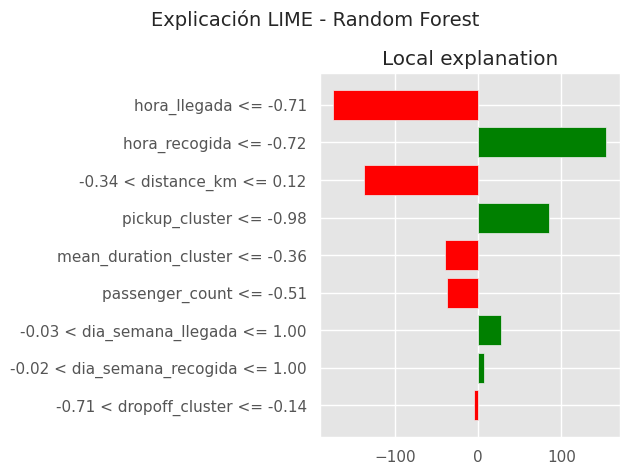


🔷 XGBoost
Explicando predicción con LIME para XGBoost...


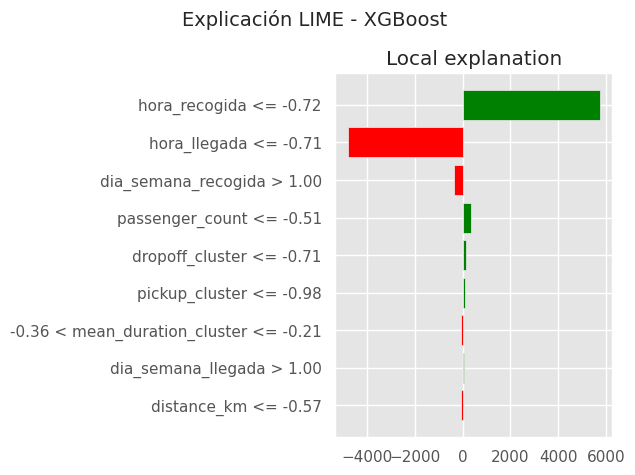


🔷 LinearSVR


In [63]:
import lime
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import joblib

# Asegúrate de tener X_train, X_test, y_train, y_test ya definidos antes

for name, (model, param_grid) in models.items():
    print(f"\n🔷 {name}")

    model_filename = f"{name.lower().replace(' ', '_')}.pkl"
    model_path = f'modelos/{model_filename}'

    if os.path.exists(model_path):
        best_model = joblib.load(model_path)
    else:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', model)
        ])
        pipeline.fit(X_train, y_train)
        joblib.dump(pipeline, model_path)
        best_model = pipeline

    # SOLO aplicar LIME si es XGBoost o Random Forest
    if name in ["XGBoost", "Random Forest"]:
        print(f"Explicando predicción con LIME para {name}...")

        # Extraer el modelo interno
        regressor = best_model.named_steps['regressor']
        scaler = best_model.named_steps['scaler']
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Instanciar el explicador LIME
        explainer = LimeTabularExplainer(
            training_data=X_train_scaled,
            feature_names=X_train.columns.tolist(),
            mode='regression'
        )

        # Elegir una instancia aleatoria a explicar
        i = np.random.randint(0, len(X_test_scaled))
        exp = explainer.explain_instance(
            data_row=X_test_scaled[i],
            predict_fn=regressor.predict
        )

        # Mostrar la gráfica de explicación
        fig = exp.as_pyplot_figure()
        fig.suptitle(f'Explicación LIME - {name}', fontsize=14)
        plt.tight_layout()
        plt.show()




#MODELOS OPTIMIZADOS

In [66]:



#Optimizados


models_opt = {
    "KNN (kd_tree)": (
        KNeighborsRegressor(algorithm='kd_tree'),
        {'regressor__n_neighbors': [3, 5, 7]}
    ),
    "Ridge (saga)": (
        Ridge(solver='saga'),
        {'regressor__alpha': [0.1, 1, 10]}
    ),
    "Lasso": (
        Lasso(),
        {'regressor__alpha': [0.01, 0.1, 1]}
    ),
    "XGBoost (hist)": (
        XGBRegressor(tree_method='hist', eval_metric='rmse', n_jobs=-1),
        {'regressor__n_estimators': [50, 100], 'regressor__max_depth': [3, 5]}
    ),
    "LinearSVR": (
        LinearSVR(max_iter=1000),
        {'regressor__C': [0.1, 1, 10], 'regressor__max_iter': [1000, 2000]}
    ),

}

gkf = GroupKFold(n_splits=5)
results_opt = []

for name, (model, param_grid) in models_opt.items():
    print(f"\n🔷 {name}")

    model_filename = f"{name.lower().replace(' ', '_').replace('(', '').replace(')', '')}.pkl"
    model_path = f'modelos_opt/{model_filename}'

    if os.path.exists(model_path):
        best_model = joblib.load(model_path)
        elapsed = None
    else:
        # Pipeline para modelos que no son RBF-RFF + Ridge
        if name != "RBF-RFF + Ridge":
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('regressor', model)
            ])
        else:
            pipeline = model

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=gkf.split(X_train, y_train, groups=groups_train),
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )

        start = time.time()
        grid.fit(X_train, y_train)
        elapsed = time.time() - start

        best_model = grid.best_estimator_
        print(f"→ Mejor RMSE CV: {-grid.best_score_:.2f}")
        print(f"→ Mejor hiperparámetro: {grid.best_params_}")
        print(f" Tiempo CPU: {elapsed:.2f} s")

        os.makedirs('modelos_opt', exist_ok=True)
        joblib.dump(best_model, model_path)

    # Evaluación sobre test set
    y_pred = best_model.predict(X_test)
    residuals = y_test - y_pred

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    ljung_pvalue = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]
    jb_stat, jb_pvalue = normal_ad(residuals)

    print(f"→ MAPE: {mape:.4f}")
    print(f"→ RMSE: {rmse:.2f}")
    print(f"→ R²: {r2:.4f}")
    print(f"→ Ljung-Box p: {ljung_pvalue:.4f}")
    print(f"→ Jarque-Bera p: {jb_pvalue:.4f}")

    results_opt.append({
        'Modelo Optimizado': name,
        'MAPE': mape,
        'RMSE': rmse,
        'R2': r2,
        'Ljung-Box p': ljung_pvalue,
        'Jarque-Bera p': jb_pvalue,
        'CPU Time (s)': elapsed
    })

df_resultados_opt = pd.DataFrame(results_opt)
display(df_resultados_opt)



🔷 KNN (kd_tree)
→ MAPE: 0.4136
→ RMSE: 327.02
→ R²: 0.7430
→ Ljung-Box p: 0.6721
→ Jarque-Bera p: 0.0000

🔷 Ridge (saga)
→ MAPE: 0.6557
→ RMSE: 406.06
→ R²: 0.6037
→ Ljung-Box p: 0.2299
→ Jarque-Bera p: 0.0000

🔷 Lasso
→ MAPE: 0.6557
→ RMSE: 406.06
→ R²: 0.6037
→ Ljung-Box p: 0.2296
→ Jarque-Bera p: 0.0000

🔷 XGBoost (hist)
→ MAPE: 0.3828
→ RMSE: 297.27
→ R²: 0.7876
→ Ljung-Box p: 0.4990
→ Jarque-Bera p: 0.0000

🔷 LinearSVR
→ MAPE: 0.5102
→ RMSE: 415.27
→ R²: 0.5855
→ Ljung-Box p: 0.2513
→ Jarque-Bera p: 0.0000


,Modelo Optimizado,MAPE,RMSE,R2,Ljung-Box p,Jarque-Bera p,CPU Time (s)
0,KNN (kd_tree),0.413592,327.017291,0.742956,0.672123,0.0,None
1,Ridge (saga),0.655705,406.058340,0.603683,0.229882,0.0,None
2,Lasso,0.655714,406.059115,0.603682,0.229580,0.0,None
3,XGBoost (hist),0.382780,297.265467,0.787600,0.498951,0.0,None
4,LinearSVR,0.510213,415.272679,0.585493,0.251331,0.0,None


#MODELO ORIGINAL

In [70]:
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# Modelos base
estimators = [
    ('xgb', XGBRegressor(n_estimators=100, max_depth=3, eval_metric='rmse', n_jobs=-1)),
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1)),
    ('knn', Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=5))
    ])),
]

# Meta-modelo
final_estimator = Ridge(alpha=1.0)

stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5,
    n_jobs=-1
)

# Entrenamiento y evaluación
model_name = "Stacking_XGB_RF_KNN"
model_path = f"modelos_opt/{model_name}.pkl"

if os.path.exists(model_path):
    best_model = joblib.load(model_path)
    elapsed = None
else:
    start = time.time()
    best_model = stack_model.fit(X_train, y_train)
    elapsed = time.time() - start
    os.makedirs("modelos_opt", exist_ok=True)
    joblib.dump(best_model, model_path)

# Evaluación
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
ljung_pvalue = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]
jb_stat, jb_pvalue = normal_ad(residuals)

# Mostrar resultados
print(f"\n🔶 Modelo Original: {model_name}")
print(f"→ MAPE: {mape:.4f}")
print(f"→ RMSE: {rmse:.2f}")
print(f"→ R²: {r2:.4f}")
print(f"→ Ljung-Box p: {ljung_pvalue:.4f}")
print(f"→ Jarque-Bera p: {jb_pvalue:.4f}")

# Guardar en tabla
results_opt.append({
    'Modelo Optimizado': model_name,
    'MAPE': mape,
    'RMSE': rmse,
    'R2': r2,
    'Ljung-Box p': ljung_pvalue,
    'Jarque-Bera p': jb_pvalue,
    'CPU Time (s)': elapsed
})

df_resultados_opt = pd.DataFrame(results_opt)
display(df_resultados_opt)



🔶 Modelo Original: Stacking_XGB_RF_KNN
→ MAPE: 0.3978
→ RMSE: 309.22
→ R²: 0.7702
→ Ljung-Box p: 0.5658
→ Jarque-Bera p: 0.0000


,Modelo Optimizado,MAPE,RMSE,R2,Ljung-Box p,Jarque-Bera p,CPU Time (s)
0,KNN (kd_tree),0.413592,327.017291,0.742956,0.672123,0.0,NaN
1,Ridge (saga),0.655705,406.058340,0.603683,0.229882,0.0,NaN
2,Lasso,0.655714,406.059115,0.603682,0.229580,0.0,NaN
3,XGBoost (hist),0.382780,297.265467,0.787600,0.498951,0.0,NaN
4,LinearSVR,0.510213,415.272679,0.585493,0.251331,0.0,NaN
5,Stacking_XGB_Ridge,0.418999,315.778017,0.760321,0.573230,0.0,15.871040
6,Stacking_XGB_Ridge,0.418999,315.778017,0.760321,0.573230,0.0,NaN
7,Stacking_XGB_RF_KNN,0.397814,309.219166,0.770175,0.565795,0.0,468.925647
8,Stacking_XGB_RF_KNN,0.397814,309.219166,0.770175,0.565795,0.0,NaN


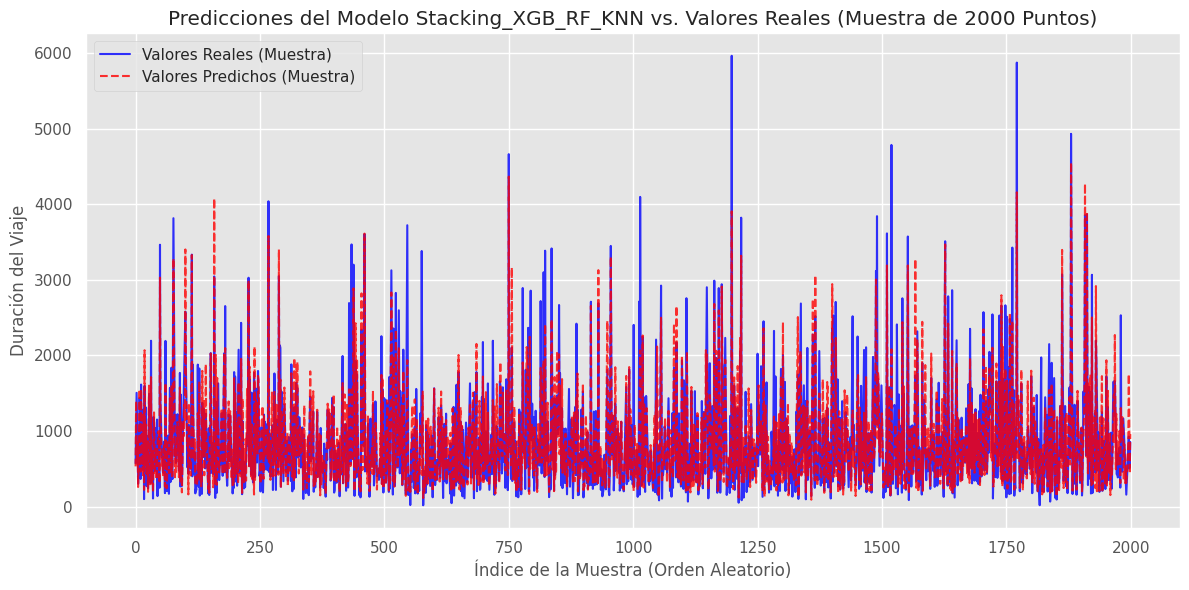

In [90]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['agg.path.chunksize'] = 10000
plt.rcParams['path.simplify_threshold'] = 1.0


# --- MUESTREO DE DATOS PARA LA GRÁFICA ---

if hasattr(y_test, 'numpy'):
    y_test_array = y_test.numpy()
else:
    y_test_array = np.asarray(y_test)

if hasattr(y_pred, 'numpy'):
    y_pred_array = y_pred.numpy()
else:
    y_pred_array = np.asarray(y_pred)


# Número de puntos para la muestra
sample_size = 2000

actual_data_size = len(y_test_array)
actual_sample_size = min(actual_data_size, sample_size)

# Generar índices aleatorios para la muestra

sample_indices = np.random.choice(np.arange(actual_data_size), actual_sample_size, replace=False)

# Seleccionar los datos de la muestra usando los índices aleatorios
y_test_sample = y_test_array[sample_indices]
y_pred_sample = y_pred_array[sample_indices]


x_axis_sample = np.arange(actual_sample_size)


# --- Generar la Gráfica de Predicciones vs Valores Reales (Solo Muestra) ---
plt.figure(figsize=(12, 6))

# Usamos x_axis_sample para el eje X
plt.plot(x_axis_sample, y_test_sample, label='Valores Reales (Muestra)', color='blue', alpha=0.8)
plt.plot(x_axis_sample, y_pred_sample, label='Valores Predichos (Muestra)', color='red', linestyle='--', alpha=0.8)

plt.title(f'Predicciones del Modelo {model_name} vs. Valores Reales (Muestra de {actual_sample_size} Puntos)')
plt.xlabel('Índice de la Muestra (Orden Aleatorio)')
plt.ylabel('Duración del Viaje')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()